# Практическое задание на тему «Регрессионный анализ и меры связи»

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Загрузка и просмотр данных

In [ ]:
df = pd.read_excel('data_hw_reg.xlsx')
df.head()

,date,country,confirmed,deaths
0,2020-01-22,Russia,0,0
1,2020-01-22,US,1,0
2,2020-01-23,Russia,0,0
3,2020-01-23,US,1,0
4,2020-01-24,Russia,0,0


In [ ]:
# общая информация, видим, что пропусков нет
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1116 non-null   datetime64[ns]
 1   country    1116 non-null   object        
 2   confirmed  1116 non-null   int64         
 3   deaths     1116 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 35.0+ KB


In [ ]:
df.describe()

,date,confirmed,deaths
count,1116,1.116000e+03,1116.000000
mean,2020-10-26 12:00:00,8.508892e+06,169543.963262
min,2020-01-22 00:00:00,0.000000e+00,0.000000
25%,2020-06-09 00:00:00,8.245898e+05,15199.000000
50%,2020-10-26 12:00:00,3.840895e+06,98314.000000
75%,2021-03-15 00:00:00,8.748694e+06,226763.000000
max,2021-08-01 00:00:00,3.500342e+07,613228.000000
std,NaN,1.130533e+07,198133.420131


In [ ]:
# Корреляция смертности к заболеваемости
df['deaths'].corr(df['confirmed'])

np.float64(0.9898359549904745)

In [ ]:
df[['confirmed', 'deaths']].corr()

,confirmed,deaths
confirmed,1.000000,0.989836
deaths,0.989836,1.000000


In [ ]:
# Формирование выборки
df_rus = df[df['country'] == 'Russia']
df_rus

,date,country,confirmed,deaths
0,2020-01-22,Russia,0,0
2,2020-01-23,Russia,0,0
4,2020-01-24,Russia,0,0
6,2020-01-25,Russia,0,0
8,2020-01-26,Russia,0,0
...,...,...,...,...
1106,2021-07-28,Russia,6116249,153620
1108,2021-07-29,Russia,6138969,154404
1110,2021-07-30,Russia,6161985,155180
1112,2021-07-31,Russia,6185249,155952


In [ ]:
# Формирование выборки
df_usa = df[df['country'] == 'US']
df_usa

,date,country,confirmed,deaths
1,2020-01-22,US,1,0
3,2020-01-23,US,1,0
5,2020-01-24,US,2,0
7,2020-01-25,US,2,0
9,2020-01-26,US,5,0
...,...,...,...,...
1107,2021-07-28,US,34672690,611803
1109,2021-07-29,US,34750860,612124
1111,2021-07-30,US,34945468,613013
1113,2021-07-31,US,34978276,613157


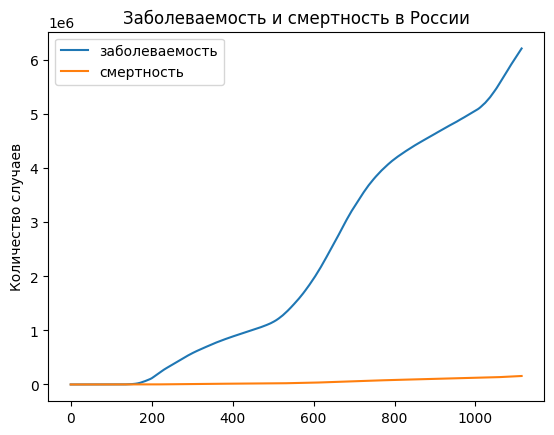

In [ ]:
# График динамики заболеваний и смертей
plt.plot(df_rus['confirmed'])
plt.plot(df_rus['deaths'])
plt.legend(['заболеваемость', 'смертность'])
plt.title('Заболеваемость и смертность в России')
plt.ylabel('Количество случаев')
plt.show()

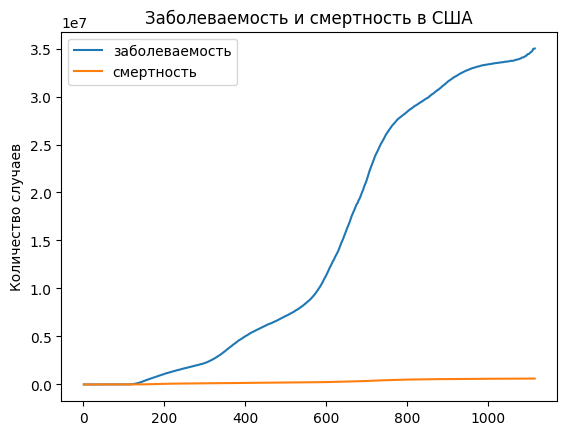

In [ ]:
plt.plot(df_usa['confirmed'])
plt.plot(df_usa['deaths'])
plt.legend(['заболеваемость', 'смертность'])
plt.title('Заболеваемость и смертность в США')
plt.ylabel('Количество случаев')
plt.show()

In [ ]:
# Матрица корреляции средствами pandas
df_rus[['confirmed', 'deaths']].corr().style.background_gradient(cmap='coolwarm')

,confirmed,deaths
confirmed,1.000000,0.989910
deaths,0.989910,1.000000


<Axes: >

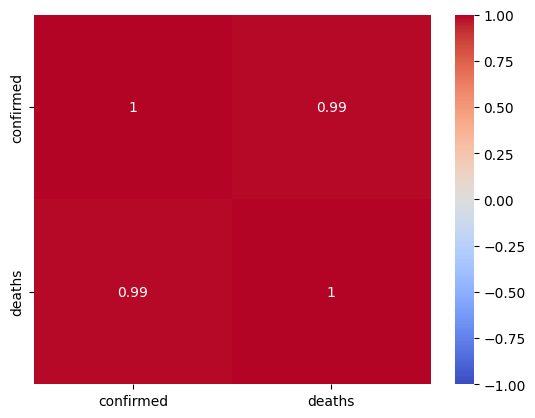

In [ ]:
# Матрица корреляции средствами визуализации seaborn (тепловая матрица)
sns.heatmap(df_rus[['confirmed', 'deaths']].corr(), annot = True, vmin=-1, vmax=1, center= 0, cmap= 'coolwarm')

# Построение линейной регрессии

In [ ]:
# Формируем выборку по России (смертность - зависимая переменная)
x_train = df_rus[['confirmed']]
y_train = df_rus[['deaths']]

In [ ]:
from sklearn.linear_model import LinearRegression # Подключение модуля Линейной регрессии
regressor = LinearRegression()                    # Инициализация Линейной регрессии
regressor.fit(x_train, y_train)                   # Обучение Линейной регрессии

LinearRegression()

In [ ]:
# Коэффициент прямой
a = regressor.intercept_
a

array([-5713.82792078])

In [ ]:
# Коэффициент наклона прямой
b = regressor.coef_
b

array([[0.02352537]])

In [ ]:
confirmed_predict = 25000000    # Значение случаев заражения для получения прогноза смертности
int(regressor.predict([[confirmed_predict]]))   # Получение прогноза Линейной регрессии (с округлением к целому)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_1345/4006033663.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(regressor.predict([[confirmed_predict]]))   # Получение прогноза Линейной регрессии (с округлением к целому)


582420

Уравнение линейной регрессии по смертям от заболеваемости в РФ имеет вид:


```
-5713.83 + 0.02*x
```



In [ ]:
# Получение прогноза "в лоб" по уровнению прямой регрессии a + bx
int(a + b * confirmed_predict)

/tmp/ipykernel_1345/69233014.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(a + b * confirmed_predict)


582420

- Заболеваемость и смертность явно коррелирует
- Заболеваемость и смертность растёт
- Темп распространения берётся под контроль